In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import kendalltau, pearsonr, spearmanr

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight

# Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
    learning_curve,
    cross_validate
)

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    RocCurveDisplay,
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import xgboost as xgb
import lightgbm as lgb

# Outlier handling
from feature_engine.outliers import Winsorizer

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# 1. Load & Clean cs-test.csv
import pandas as pd
import numpy as np

test_df = pd.read_csv("cs-test.csv")
test_df.drop(columns=["Unnamed: 0", "SeriousDlqin2yrs"], errors="ignore", inplace=True)

print(f"Shape awal            : {test_df.shape}")
print(f"Duplikat              : {test_df.duplicated().sum():,} baris")
print(f"Missing per kolom:")
print(test_df.isna().sum())

# Drop duplikat
test_df = test_df.drop_duplicates()
print(f"Shape setelah drop duplikat : {test_df.shape}")

# Drop baris yang ada missing value di kolom manapun
test_df = test_df.dropna()
print(f"Shape setelah drop missing  : {test_df.shape}")
print(f"Total baris dibuang         : {101503 - len(test_df):,}")

test_df = test_df.reset_index(drop=True)
print(f"Data siap untuk inference ✓")

Shape awal            : (101503, 10)
Duplikat              : 328 baris
Missing per kolom:
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           20103
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2626
dtype: int64
Shape setelah drop duplikat : (101175, 10)
Shape setelah drop missing  : (81349, 10)
Total baris dibuang         : 20,154
Data siap untuk inference ✓


In [ ]:
# 2. Load Artefak
import joblib, json

loaded_lgbm        = joblib.load("saved_models/best_lgbm.pkl")
loaded_transformer = joblib.load("saved_models/transformer.pkl")

with open("saved_models/metadata.json") as f:
    meta = json.load(f)

FEATURE_NAMES = meta["feature_names"]
print("Model & transformer berhasil di-load ✓")
print(f"Features: {FEATURE_NAMES}")

Model & transformer berhasil di-load ✓
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'WeightedLateScore', 'LogIncome', 'DisposableIncome', 'LogDebtRatio']


In [ ]:
# 3. Preprocessing — Seluruh Data
def preprocess(df):
    df = df.copy()

    # Capping continuous (percentile 1-99% dari training)
    clip_bounds = {
        "RevolvingUtilizationOfUnsecuredLines": (0.0,    1.1266),
        "DebtRatio":                            (0.0,    4931.0),
        "MonthlyIncome":                        (0.0,   25000.0),
    }
    for col, (lo, hi) in clip_bounds.items():
        df[col] = df[col].clip(lo, hi)

    # Log transform utilization
    df["RevolvingUtilizationOfUnsecuredLines"] = np.log1p(
        df["RevolvingUtilizationOfUnsecuredLines"]
    )

    # Capping count columns (hard cap 0-10)
    count_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberRealEstateLoansOrLines",
        "NumberOfDependents",
    ]
    for col in count_cols:
        df[col] = df[col].clip(0, 10)

    # Filter age
    df = df[(df["age"] >= 18) & (df["age"] <= 100)].reset_index(drop=True)

    # Feature creation
    df["WeightedLateScore"] = (
        df["NumberOfTime30-59DaysPastDueNotWorse"] * 1 +
        df["NumberOfTime60-89DaysPastDueNotWorse"] * 2 +
        df["NumberOfTimes90DaysLate"]              * 4
    )
    df["LogIncome"]        = np.log1p(df["MonthlyIncome"])
    df["DisposableIncome"] = df["MonthlyIncome"] * (1 - df["DebtRatio"])
    df["LogDebtRatio"]     = np.log1p(df["DebtRatio"])

    return df[FEATURE_NAMES]

# Apply ke seluruh test data
test_processed = preprocess(test_df)
print(f"Shape setelah preprocessing : {test_processed.shape}")
print(f"Sample 5 baris pertama:")
print(test_processed.head())

Shape setelah preprocessing : (81348, 9)
Sample 5 baris pertama:
   RevolvingUtilizationOfUnsecuredLines  age  NumberOfOpenCreditLinesAndLoans  \
0                              0.634203   43                                4   
1                              0.380691   57                               10   
2                              0.042365   59                               10   
3                              0.247101   38                                7   
4                              0.693147   27                                4   

   NumberRealEstateLoansOrLines  NumberOfDependents  WeightedLateScore  \
0                             0                 0.0                  0   
1                             4                 2.0                  0   
2                             1                 2.0                  0   
3                             2                 0.0                  1   
4                             0                 1.0                  0   

   

In [ ]:
# 4. Scaling & Prediksi Seluruh Data
test_scaled = loaded_transformer.transform(test_processed)
y_proba_all = loaded_lgbm.predict_proba(test_scaled)[:, 1]

print(f"Total prediksi  : {len(y_proba_all):,} baris")
print(f"Range prob      : {y_proba_all.min()*100:.2f}% — {y_proba_all.max()*100:.2f}%")
print(f"Mean prob       : {y_proba_all.mean()*100:.2f}%")

c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Total prediksi  : 81,348 baris
Range prob      : 2.34% — 98.80%
Mean prob       : 33.52%


In [ ]:
# 5. Re-generate X_test_final & y_test dari training data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Load & preprocessing (replikasi pipeline training)
df = pd.read_csv("cs-training.csv")
df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)
df = df.drop_duplicates()
df = df[(df["age"] >= 18) & (df["age"] <= 100)].reset_index(drop=True)

df_fe = df.copy()

# Missing value
df_fe["MonthlyIncome"].fillna(df_fe["MonthlyIncome"].median(), inplace=True)
df_fe["NumberOfDependents"].fillna(df_fe["NumberOfDependents"].median(), inplace=True)

# Capping continuous
continuous_cols = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]
for col in continuous_cols:
    lower = df_fe[col].quantile(0.01)
    upper = df_fe[col].quantile(0.99)
    df_fe[col] = df_fe[col].clip(lower, upper)

# Log transform utilization
df_fe["RevolvingUtilizationOfUnsecuredLines"] = np.log1p(
    df_fe["RevolvingUtilizationOfUnsecuredLines"]
)

# Capping count columns
count_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
]
for col in count_cols:
    df_fe[col] = df_fe[col].clip(0, 10)

# Feature creation
df_fe["WeightedLateScore"] = (
    df_fe["NumberOfTime30-59DaysPastDueNotWorse"] * 1 +
    df_fe["NumberOfTime60-89DaysPastDueNotWorse"] * 2 +
    df_fe["NumberOfTimes90DaysLate"]              * 4
)
df_fe["LogIncome"]        = np.log1p(df_fe["MonthlyIncome"])
df_fe["DisposableIncome"] = df_fe["MonthlyIncome"] * (1 - df_fe["DebtRatio"])
df_fe["LogDebtRatio"]     = np.log1p(df_fe["DebtRatio"])

# Feature selection (sama persis saat training)
cols_to_drop = [
    "NumberOfTimes90DaysLate",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "MonthlyIncome",
    "DebtRatio",
    "MonthlyDebt" if "MonthlyDebt" in df_fe.columns else None,
    "DependentsMissingFlag" if "DependentsMissingFlag" in df_fe.columns else None,
    "IncomeMissingFlag" if "IncomeMissingFlag" in df_fe.columns else None,
]
cols_to_drop = [c for c in cols_to_drop if c and c in df_fe.columns]
df_fe = df_fe.drop(columns=cols_to_drop)

# Split
X = df_fe.drop(columns=["SeriousDlqin2yrs"])
y = df_fe["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling — load transformer yang sudah disimpan
X_train_final = loaded_transformer.transform(X_train)
X_test_final  = loaded_transformer.transform(X_test)

print(f"X_test_final shape : {X_test_final.shape}")
print(f"y_test distribution:\n{y_test.value_counts()}")
print("Re-generate selesai ✓")

X_test_final shape : (29876, 9)
y_test distribution:
SeriousDlqin2yrs
0    27874
1     2002
Name: count, dtype: int64
Re-generate selesai ✓


C:\Users\rezha\AppData\Local\Temp\ipykernel_28364\1449787611.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe["MonthlyIncome"].fillna(df_fe["MonthlyIncome"].median(), inplace=True)
C:\Users\rezha\AppData\Local\Temp\ipykernel_28364\1449787611.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [ ]:
# 6. Tentukan threshold dari KS Statistic
# --- Hitung ulang KS threshold dari data test yang ada labelnya ---
y_prob_eval = loaded_lgbm.predict_proba(X_test_final)[:, 1] 

df_ks = pd.DataFrame({"y_true": y_test.values, "y_score": y_prob_eval})
df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)

total_bad  = df_ks["y_true"].sum()
total_good = len(df_ks) - total_bad

df_ks["cum_bad"]       = df_ks["y_true"].cumsum()
df_ks["cum_good"]      = (1 - df_ks["y_true"]).cumsum()
df_ks["cum_bad_rate"]  = df_ks["cum_bad"]  / total_bad
df_ks["cum_good_rate"] = df_ks["cum_good"] / total_good
df_ks["KS"]            = (df_ks["cum_bad_rate"] - df_ks["cum_good_rate"]).abs()

ks_stat      = df_ks["KS"].max()
ks_threshold = df_ks.loc[df_ks["KS"].idxmax(), "y_score"]

print(f"KS Statistic : {ks_stat:.4f}")
print(f"KS Threshold : {ks_threshold:.4f}  ← batas High vs Low Risk")
print(f"\nInterpretasi (dari artikel):")
print(f"  KS = {ks_stat:.2f} → ", end="")
if ks_stat >= 0.5:
    print("Good model (50–70+)")
elif ks_stat >= 0.2:
    print("Acceptable model (20–40)")
else:
    print("Weak model (<20)")

c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


KS Statistic : 0.5836
KS Threshold : 0.4866  ← batas High vs Low Risk

Interpretasi (dari artikel):
  KS = 0.58 → Good model (50–70+)


In [ ]:
# 7. Risk Categorization berbasis KS Threshold
margin     = ks_threshold * 0.10
high_bound = ks_threshold + margin
low_bound  = ks_threshold - margin

print(f"Batas kategori (berbasis KS threshold = {ks_threshold:.4f}):")
print(f"  🔴 High Risk   : probabilitas >= {high_bound*100:.1f}%")
print(f"  🟡 Medium Risk : {low_bound*100:.1f}% ≤ probabilitas < {high_bound*100:.1f}%")
print(f"  🟢 Low Risk    : probabilitas <  {low_bound*100:.1f}%")

def assign_risk(prob):
    if prob >= high_bound:
        return "🔴 High Risk"
    elif prob >= low_bound:
        return "🟡 Medium Risk"
    else:
        return "🟢 Low Risk"

risk_labels_all = [assign_risk(p) for p in y_proba_all]

Batas kategori (berbasis KS threshold = 0.4866):
  🔴 High Risk   : probabilitas >= 53.5%
  🟡 Medium Risk : 43.8% ≤ probabilitas < 53.5%
  🟢 Low Risk    : probabilitas <  43.8%


In [ ]:
# 8. Tabel Hasil Inference — Seluruh Data
result_all = test_df.loc[test_processed.index].copy().reset_index(drop=True)
result_all["Prob. Default (%)"] = (y_proba_all * 100).round(2)
result_all["Risk Category"]     = risk_labels_all

print(f"=== Hasil Inference — {len(result_all):,} Peminjam ===")
print(f"Sample 20 baris pertama:")

display_cols = [
    "age", "RevolvingUtilizationOfUnsecuredLines", "DebtRatio",
    "MonthlyIncome", "NumberOfDependents",
    "Prob. Default (%)", "Risk Category"
]
print(result_all[display_cols].head(20).to_string(index=True))

=== Hasil Inference — 81,348 Peminjam ===
Sample 20 baris pertama:
    age  RevolvingUtilizationOfUnsecuredLines    DebtRatio  MonthlyIncome  NumberOfDependents  Prob. Default (%)  Risk Category
0    43                              0.885519     0.177513         5700.0                 0.0              48.70  🟡 Medium Risk
1    57                              0.463295     0.527237         9141.0                 2.0              37.44     🟢 Low Risk
2    59                              0.043275     0.687648         5083.0                 2.0              19.10     🟢 Low Risk
3    38                              0.280308     0.925961         3200.0                 0.0              53.54    🔴 High Risk
4    27                              1.000000     0.019917         3865.0                 1.0              59.53    🔴 High Risk
5    63                              0.509791     0.342429         4140.0                 1.0              32.25     🟢 Low Risk
6    50                              

In [ ]:
# 9. Ringkasan Distribusi Risk
from collections import Counter

counts = Counter(risk_labels_all)
total  = len(risk_labels_all)

print("=== Distribusi Risk Category — Seluruh Data ===")
print(f"{'Kategori':<20} {'Jumlah':>10} {'Persentase':>12}")
print("-" * 45)
for cat in ["🔴 High Risk", "🟡 Medium Risk", "🟢 Low Risk"]:
    n = counts.get(cat, 0)
    print(f"{cat:<20} {n:>10,} {n/total*100:>11.2f}%")
print("-" * 45)
print(f"{'Total':<20} {total:>10,} {'100.00%':>12}")

=== Distribusi Risk Category — Seluruh Data ===
Kategori                 Jumlah   Persentase
---------------------------------------------
🔴 High Risk              18,094       22.24%
🟡 Medium Risk             6,564        8.07%
🟢 Low Risk               56,690       69.69%
---------------------------------------------
Total                    81,348      100.00%


C:\Users\rezha\AppData\Local\Temp\ipykernel_28364\706954125.py:54: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rezha\AppData\Local\Temp\ipykernel_28364\706954125.py:54: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\rezha\AppData\Local\Temp\ipykernel_28364\706954125.py:54: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\rezha\anaconda3\envs\h8_env\lib\site-packages\

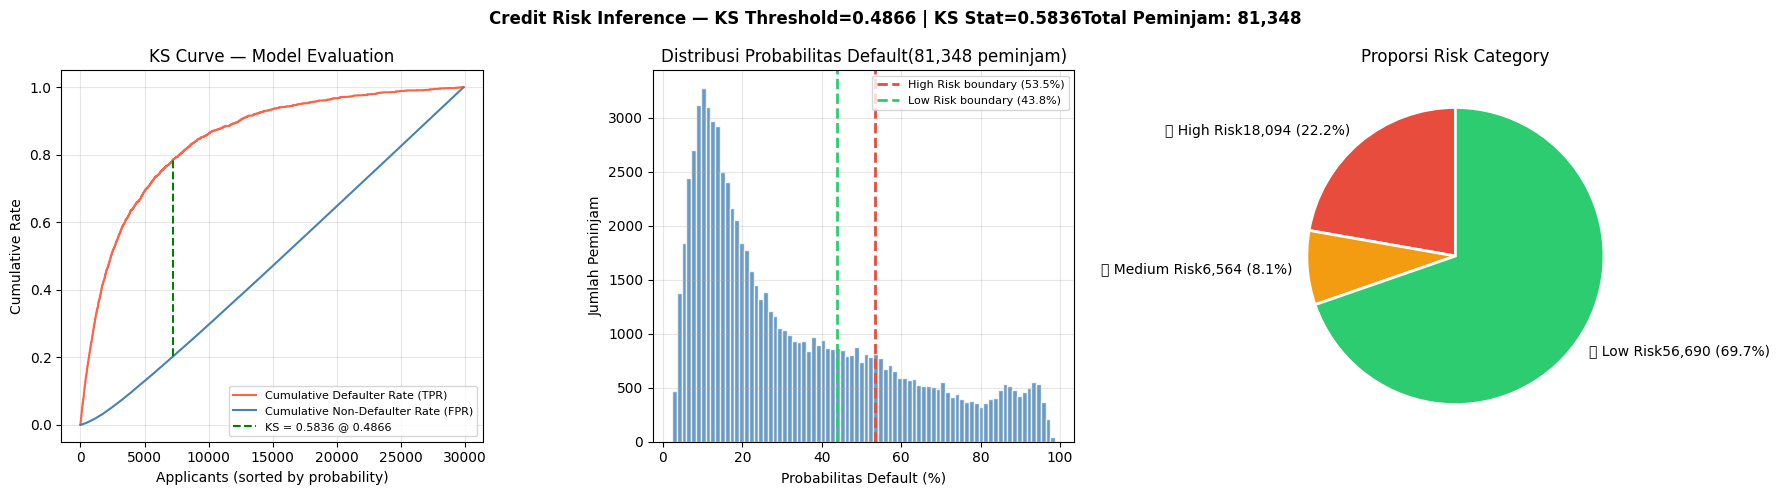

In [ ]:
# 10. Visualisasi
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: KS Curve
axes[0].plot(df_ks.index, df_ks["cum_bad_rate"],
             label="Cumulative Defaulter Rate (TPR)", color="tomato")
axes[0].plot(df_ks.index, df_ks["cum_good_rate"],
             label="Cumulative Non-Defaulter Rate (FPR)", color="steelblue")
ks_idx = df_ks["KS"].idxmax()
axes[0].vlines(x=ks_idx,
               ymin=df_ks.loc[ks_idx, "cum_good_rate"],
               ymax=df_ks.loc[ks_idx, "cum_bad_rate"],
               colors="green", linestyles="--",
               label=f"KS = {ks_stat:.4f} @ {ks_threshold:.4f}")
axes[0].set_xlabel("Applicants (sorted by probability)")
axes[0].set_ylabel("Cumulative Rate")
axes[0].set_title("KS Curve — Model Evaluation")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Plot 2: Distribusi probabilitas seluruh data
axes[1].hist(y_proba_all * 100, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(high_bound * 100, color="#e74c3c", linestyle="--", linewidth=2,
                label=f"High Risk boundary ({high_bound*100:.1f}%)")
axes[1].axvline(low_bound  * 100, color="#2ecc71", linestyle="--", linewidth=2,
                label=f"Low Risk boundary ({low_bound*100:.1f}%)")
axes[1].set_xlabel("Probabilitas Default (%)")
axes[1].set_ylabel("Jumlah Peminjam")
axes[1].set_title(f"Distribusi Probabilitas Default({len(y_proba_all):,} peminjam)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Plot 3: Pie chart risk category
counts  = Counter(risk_labels_all)
cat_order  = ["🔴 High Risk", "🟡 Medium Risk", "🟢 Low Risk"]
cat_colors = ["#e74c3c", "#f39c12", "#2ecc71"]
cat_counts = [counts.get(c, 0) for c in cat_order]
cat_labels = [f"{c}{n:,} ({n/total*100:.1f}%)" 
              for c, n in zip(cat_order, cat_counts)]

axes[2].pie(cat_counts, labels=cat_labels, colors=cat_colors,
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[2].set_title("Proporsi Risk Category")

plt.suptitle(
    f"Credit Risk Inference — KS Threshold={ks_threshold:.4f} | KS Stat={ks_stat:.4f}"
    f"Total Peminjam: {len(y_proba_all):,}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [18]:
# ── 10. Export Hasil ke CSV ──────────────────────────────────
output_cols = list(test_df.columns) + ["Prob. Default (%)", "Risk Category"]
result_all[output_cols].to_csv("inference_result.csv", index=False)

print(f"Hasil inference disimpan ke: inference_result.csv")
print(f"Total baris : {len(result_all):,}")
print(f"Preview:")
print(result_all[["age", "MonthlyIncome", "Prob. Default (%)", "Risk Category"]].head(5))

Hasil inference disimpan ke: inference_result.csv
Total baris : 81,348
Preview:
   age  MonthlyIncome  Prob. Default (%)  Risk Category
0   43         5700.0              48.70  🟡 Medium Risk
1   57         9141.0              37.44     🟢 Low Risk
2   59         5083.0              19.10     🟢 Low Risk
3   38         3200.0              53.54    🔴 High Risk
4   27         3865.0              59.53    🔴 High Risk
